Text(0.5, 1.0, 'Gray / Binary / Eroded')

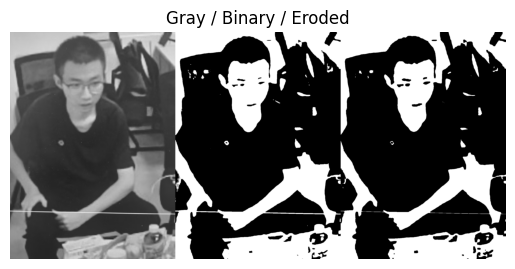

In [244]:
#图像腐蚀运算
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zb.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('图片路径错误或文件不存在')

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) 

#定义腐蚀核
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
eroded = cv2.erode(binary, kernel, iterations=1)

vis = np.hstack([gray, binary, eroded]) 
vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.imshow(vis)
plt.axis('off')
plt.title('Gray / Binary / Eroded')

Text(0.5, 1.0, 'Gray / Binary / Dilated')

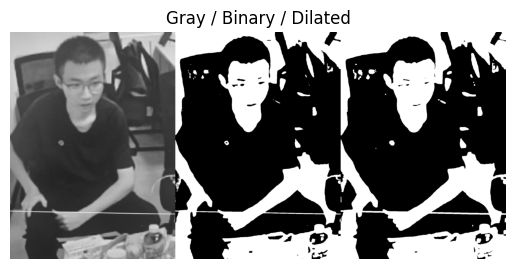

In [245]:
#图像膨胀运算
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zb.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('图片路径错误或文件不存在')

#图像灰度处理与二值化
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#前景为黑色->THRESH_BINARY
#前景为白色->THRESH_BINARY_INV

#定义膨胀核
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
dilated = cv2.dilate(binary, kernel, iterations=1)

vis = np.hstack([gray, binary, dilated])
vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.imshow(vis)
plt.axis('off')
plt.title('Gray / Binary / Dilated')

(np.float64(-0.5), np.float64(3071.5), np.float64(1407.5), np.float64(-0.5))

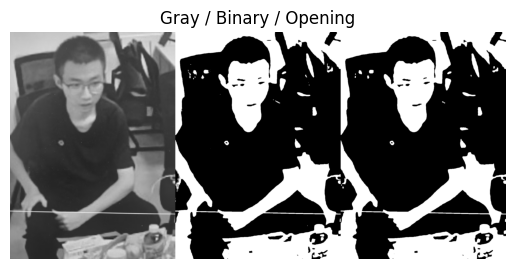

In [246]:
#图像开运算
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zb.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('图片路径错误或文件不存在')

#灰度变换与二值化
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#定义结构元
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)

vis = np.hstack([gray, binary, opening])
vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.imshow(vis)
plt.title('Gray / Binary / Opening')
plt.axis('off')

(np.float64(-0.5), np.float64(3071.5), np.float64(1407.5), np.float64(-0.5))

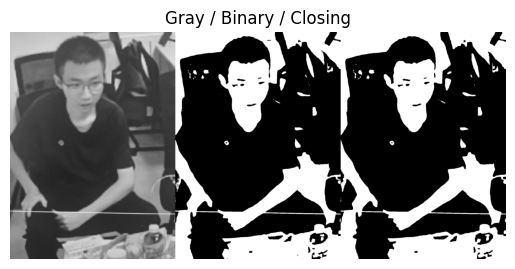

In [247]:
#图像闭运算
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zb.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('图片路径错误或文件不存在')

#灰度变换与二值化
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#定义结构元
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)

vis = np.hstack([gray, binary, closing])
vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.imshow(vis)
plt.title('Gray / Binary / Closing')
plt.axis('off')


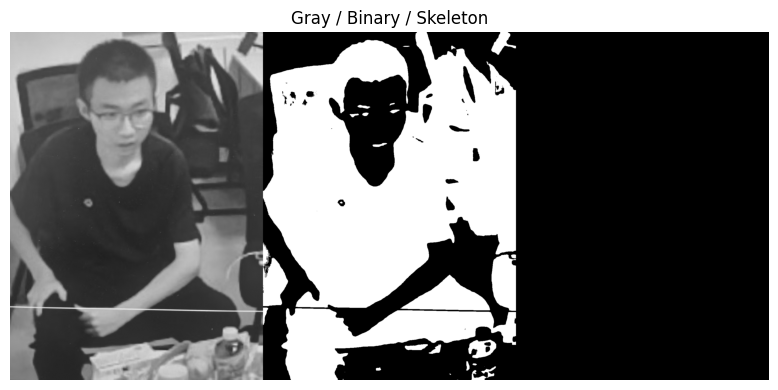

In [248]:
# 骨架操作
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.util import img_as_bool
#OpenCV没有单步骨架API，采用Zhang-Suen快速并行细化算法, 安装scikit-image

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zb.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('图片路径错误或文件不存在')

#灰度转换与二值化
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

binary_bool = img_as_bool(binary // 255)
skeleton = skeletonize(binary_bool)

skeleton_uint8 = skeleton.astype(np.uint8) * 255
kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
skeleton_thick = cv2.dilate(skeleton_uint8, kernel, iterations=1)

vis = np.hstack([gray, binary, skeleton_thick])
plt.figure(figsize=(12,4))
plt.imshow(vis, cmap='gray')
plt.title('Gray / Binary / Skeleton')
plt.axis('off')
plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(3071.5), np.float64(1407.5), np.float64(-0.5))

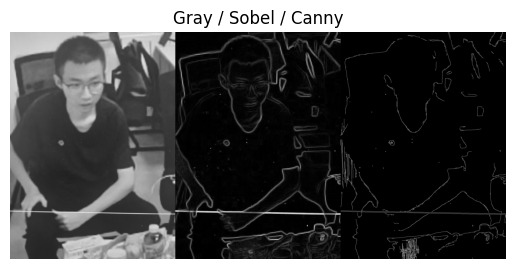

In [249]:
#边缘检测
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zb.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('图片路径错误')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Sobel算子
sobelx = cv2.Sobel(gray, cv2.CV_16S, 1, 0, ksize=3) #水平梯度
sobely = cv2.Sobel(gray, cv2.CV_16S, 0, 1, ksize=3) #垂直梯度
sobel_f = cv2.magnitude(sobelx.astype(np.float32), sobely.astype(np.float32)) #合成梯度幅值
sobel = cv2.convertScaleAbs(sobel_f) #转8位

#Canny算子
canny = cv2.Canny(gray, 10, 100)

vis = np.hstack([gray, sobel, canny])
vis = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
plt.imshow(vis)
plt.title('Gray / Sobel / Canny')
plt.axis('off')

/Users/guo2006/myenv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guo2006/myenv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guo2006/myenv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guo2006/myenv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/guo2006/myenv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/guo2006/myenv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


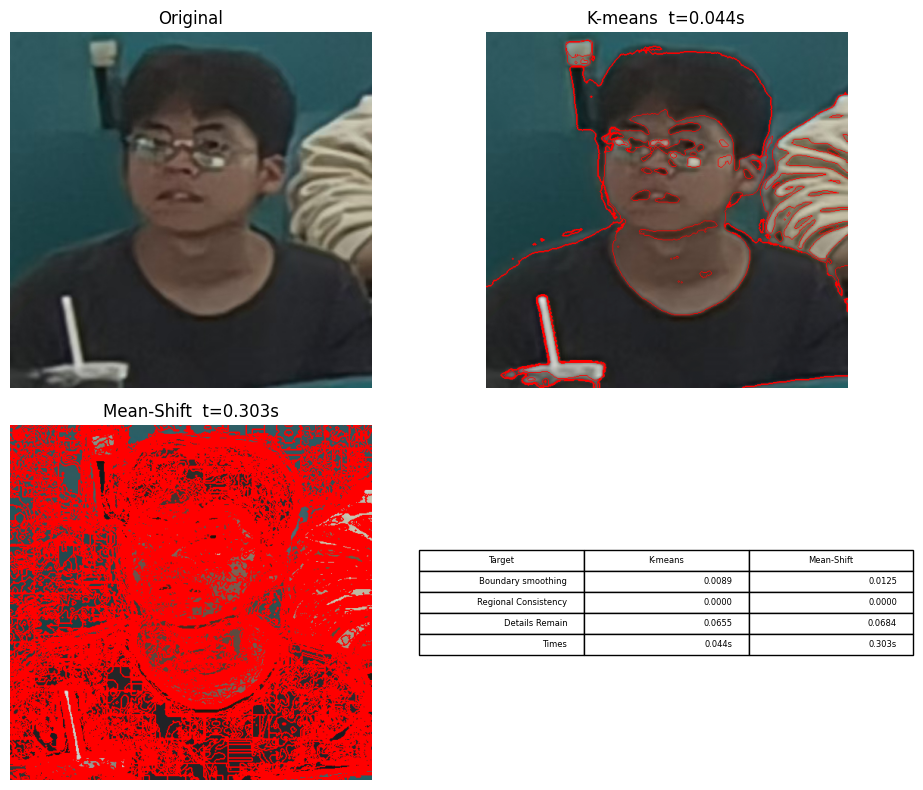

In [ ]:
#附加
import cv2, numpy as np, time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
from skimage.segmentation import slic, mark_boundaries
from skimage.filters import sobel

img_path = '/Users/guo2006/myenv/Machine Vision Experiment/Machine Vision Experiment 4/zxc.jpg'
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError('路径错误')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, c = img_rgb.shape
data = img_rgb.reshape(-1, 3)

#K-means
t0 = time.time()
kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto').fit(data)
kmeans_label = kmeans.labels_.reshape(h, w)
kmeans_seg = kmeans.cluster_centers_[kmeans_label].astype(np.uint8)
tk = time.time() - t0

#Mean-Shift
t0 = time.time()
# 先用 SLIC 超像素加速 Mean-Shift，否则 2K×1K 图会跑不动
segments = slic(img_rgb, n_segments=500, compactness=10, start_label=0)
seg_centers = np.array([data[segments.reshape(-1) == i].mean(axis=0)
                        for i in np.unique(segments)])
ms_labels = pairwise_distances_argmin(data, seg_centers).reshape(h, w)
mean_shift_seg = seg_centers[ms_labels].astype(np.uint8)
tm = time.time() - t0

#评价指标函数
def boundary_smoothness(seg_gray):
    """沿分割边界的梯度均值，越小越平滑"""
    edge = sobel(seg_gray)
    return edge.mean()

def region_consistency(seg_lab, label_map):
    """各区域内部方差均值，越小越一致"""
    var = []
    for l in np.unique(label_map):
        mask = label_map == l
        var.append(seg_lab[mask].var(axis=0).mean())
    return np.mean(var)

def detail_preservation(seg_gray):
    """边缘像素占比，越高细节越多"""
    edge = sobel(seg_gray)
    return (edge > 0.05).mean()

#转灰度+计算
kmeans_gray = cv2.cvtColor(kmeans_seg, cv2.COLOR_RGB2GRAY)
ms_gray = cv2.cvtColor(mean_shift_seg, cv2.COLOR_RGB2GRAY)

k_smooth = boundary_smoothness(kmeans_gray)
ms_smooth = boundary_smoothness(ms_gray)
k_consist = region_consistency(kmeans_seg.astype(np.float32)/255., kmeans_label)
ms_consist = region_consistency(mean_shift_seg.astype(np.float32)/255., ms_labels)
k_detail = detail_preservation(kmeans_gray)
ms_detail = detail_preservation(ms_gray)

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax[0, 0].imshow(img_rgb), ax[0, 0].set_title('Original'), ax[0, 0].axis('off')
ax[0, 1].imshow(mark_boundaries(img_rgb, kmeans_label, color=(1,0,0)))
ax[0, 1].set_title(f'K-means  t={tk:.3f}s'), ax[0, 1].axis('off')
ax[1, 0].imshow(mark_boundaries(img_rgb, ms_labels, color=(1,0,0)))
ax[1, 0].set_title(f'Mean-Shift  t={tm:.3f}s'), ax[1, 0].axis('off')
ax[1, 1].axis('off')
table = [['Target', 'K-means', 'Mean-Shift'],
         ['Boundary smoothing', f'{k_smooth:.4f}', f'{ms_smooth:.4f}'],
         ['Regional Consistency', f'{k_consist:.4f}', f'{ms_consist:.4f}'],
         ['Details Remain', f'{k_detail:.4f}', f'{ms_detail:.4f}'],
         ['Times', f'{tk:.3f}s', f'{tm:.3f}s']]
ax[1, 1].table(cellText=table[1:], colLabels=table[0], loc='center')
plt.tight_layout()
plt.show()